# Cas pratique - Campagne de démarchage bancaire

## 0 - Imports

In [1]:
# Imports standards
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Affichage
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# Imports ML (à activer au fur et à mesure)
# from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

## 0.5 Traçabilité de la session

In [2]:

import sys
import subprocess
from datetime import datetime

# --- Métadonnées du dataset ---
DATASET_NAME = "Bank Marketing"
DATASET_SOURCE = "../data/bank-additional-full.csv"
DATASET_VERSION = "YYYY-MM-DD"  # date d'extraction OU version explicite

# --- Métadonnées de la session ---
session_date = datetime.now().isoformat(timespec="minutes")
py_version = sys.version.split()[0]

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except (subprocess.CalledProcessError, FileNotFoundError):
    git_commit = "non disponible (notebook hors repo Git)"

print(f"Date session : {session_date}")
print(f"Python       : {py_version}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Git commit   : {git_commit}")
print(f"Dataset      : {DATASET_NAME} (source={DATASET_SOURCE}, version={DATASET_VERSION})")

Date session : 2026-09-24T11:34
Python       : 3.12.10
NumPy        : 1.26.4
Pandas       : 2.2.2
Git commit   : 0b63947
Dataset      : Bank Marketing (source=../data/bank-additional-full.csv, version=YYYY-MM-DD)


## 1 - Cadrage métier & problème

# 1. Cadrage métier & problème

## 1.1 Contexte client

Le client est une banque de détail souhaitant améliorer l'efficacité de ses campagnes de démarchage téléphonique pour la souscription à des dépôts à terme.

Pour proposer ce type de produit d'épargne, les banques mènent régulièrement des campagnes de démarchage téléphonique.

Ces campagnes sont coûteuses et peuvent dégrader la relation client lorsqu'elles sont mal ciblées.

Le besoin métier est donc de réduire le nombre d'appels inutiles et le coût des campagnes, tout en augmentant le taux de conversion des offres.

Le recours à l'IA doit permettre d'identifier les clients les plus susceptibles de souscrire à partir de leur profil et de l'historique de leurs interactions avec la banque.


## 1.2 Énoncé du problème IA

Le problème correspond à une tâche de classification binaire.

L'objectif du modèle est de prédire, à partir des informations disponibles sur un client, si celui-ci est susceptible de souscrire à un dépôt à terme (`yes`) ou non (`no`).

La solution devra permettre d'effectuer cette prédiction avant la prise de contact afin d'aider au ciblage des campagnes.


## 1.3 Bénéficiaires & impacts

Les bénéficiaires directs de la solution sont :
- la banque ;
- les équipes chargées des campagnes commerciales, qui pourront mieux cibler les clients à contacter.

Les bénéficiaires indirects sont les clients de la banque, qui pourront être moins sollicités pour des offres qui ne les intéressent pas.

Les prédictions du modèle peuvent cependant avoir un impact sur les clients en déterminant quels profils seront davantage ou moins sollicités.


## 1.4 Critères de succès

| Type | Critère | Cible initiale (client) | Cible révisée après EDA | Justification de la révision |
|---|---|---|---|---|
| Métier | Réduire le nombre d'appels inutiles | Améliorer le ciblage des campagnes | TODO | TODO |
| Métier | Augmenter le taux de conversion | Augmenter la proportion de souscriptions parmi les clients contactés | TODO | TODO |
| Modèle | Capacité à identifier les clients susceptibles de souscrire | TODO | TODO | TODO |
| Opérationnel | Disposer d'une prédiction exploitable avant la prise de contact | Prédiction disponible avant l'appel | TODO | TODO |
| Réglementaire / éthique | Respecter les contraintes liées aux données personnelles et aux biais | Respect du cadre applicable | TODO | TODO |

Les valeurs chiffrées des objectifs modèle seront précisées après l'analyse exploratoire des données.


## 1.5 Risques éthiques & réglementaires anticipés

Plusieurs risques devront être pris en compte :

- utilisation de données personnelles pour du ciblage commercial
- risque de biais ou de traitement différencié entre certains groupes de clients
- utilisation de variables qui ne seraient pas disponibles au moment réel de la prédiction
- manque d'explicabilité du modèle

Le traitement repose sur des données personnelles. Il devra donc respecter le RGPD, notamment les principes de minimisation des données, de limitation de la finalité et de transparence.

L'AI Act devra également être pris en compte afin de déterminer les obligations applicables à la solution.


## 1.6 Synthèse cadrage

Le projet vise à améliorer le ciblage des campagnes téléphoniques d'une banque de détail afin de réduire les sollicitations inutiles et d'améliorer le taux de conversion.

La solution reposera sur un modèle de classification binaire prédisant si un client est susceptible de souscrire à un dépôt à terme.

La réussite du projet devra être évaluée à la fois selon des critères métier, techniques et opérationnels.

Le principal point de vigilance concerne l'utilisation de données personnelles et le risque de traitement différencié entre certains groupes de clients.

# 2. Identification & acquisition des données

## 2.1 Sources

Le jeu de données utilisé est `bank-additional-full.csv`, issu du dataset public **Bank Marketing** du UCI Machine Learning Repository.

Il contient 41 188 observations, 20 variables explicatives et une variable cible `y`.

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---:|---|---|---|
| UCI Machine Learning Repository – Bank Marketing | Jeu de données public | 41 188 lignes | CSV, séparateur `;` | Fichier fourni dans le cadre du projet | TODO |

**Licence : TODO — à vérifier dans la source UCI.**

## 2.2 Chargement

In [3]:
import pandas as pd

df = pd.read_csv(DATASET_SOURCE, sep=";")


## 2.3 Dictionnaire de variables

| Variable | Description | Type | Plage / valeurs | Cible ? | Sensible ? |
|---|---|---|---|---|---|
| `age` | Âge du client | Numérique | Valeur numérique | ❌ | À analyser |
| `job` | Type d'emploi | Catégorielle | admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown | ❌ | À analyser |
| `marital` | Statut marital | Catégorielle | married, single, divorced, unknown | ❌ | À analyser |
| `education` | Niveau d'éducation | Catégorielle | basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown | ❌ | À analyser |
| `default` | Crédit en défaut de paiement | Catégorielle | yes, no, unknown | ❌ | À analyser |
| `housing` | Prêt immobilier | Catégorielle | yes, no, unknown | ❌ | À analyser |
| `loan` | Prêt personnel | Catégorielle | yes, no, unknown | ❌ | À analyser |
| `contact` | Moyen de contact | Catégorielle | cellular, telephone | ❌ | ❌ |
| `month` | Mois du dernier contact | Catégorielle | jan à dec | ❌ | ❌ |
| `day_of_week` | Jour du dernier contact | Catégorielle | mon, tue, wed, thu, fri | ❌ | ❌ |
| `duration` | Durée du dernier contact en secondes | Numérique | Valeur numérique | ❌ | ❌ |
| `campaign` | Nombre de contacts pendant la campagne | Numérique | Valeur numérique | ❌ | ❌ |
| `pdays` | Jours depuis le dernier contact d'une campagne précédente | Numérique | 999 = jamais recontacté | ❌ | ❌ |
| `previous` | Nombre de contacts avant cette campagne | Numérique | Valeur numérique | ❌ | ❌ |
| `poutcome` | Résultat de la campagne précédente | Catégorielle | failure, nonexistent, success | ❌ | ❌ |
| `emp.var.rate` | Taux de variation de l'emploi | Numérique | Indicateur trimestriel | ❌ | ❌ |
| `cons.price.idx` | Indice des prix à la consommation | Numérique | Indicateur mensuel | ❌ | ❌ |
| `cons.conf.idx` | Indice de confiance des consommateurs | Numérique | Indicateur mensuel | ❌ | ❌ |
| `euribor3m` | Taux Euribor à 3 mois | Numérique | Indicateur journalier | ❌ | ❌ |
| `nr.employed` | Nombre de salariés | Numérique | Indicateur trimestriel | ❌ | ❌ |
| `y` | Souscription à un dépôt à terme | Catégorielle binaire | yes / no | ✅ | ❌ |

## 2.4 Synthèse acquisition

Le projet repose sur un jeu de données public issu du UCI Machine Learning Repository.

Il contient 41 188 observations, 20 variables explicatives et une cible binaire indiquant la souscription ou non à un dépôt à terme.

Les données couvrent plusieurs dimensions : profil socio-démographique, situation bancaire, historique des campagnes, informations sur le dernier contact et contexte socio-économique.

Plusieurs variables liées au profil du client devront faire l'objet d'une attention particulière lors de l'analyse éthique et réglementaire.

La qualité réelle des données sera évaluée lors de l'analyse exploratoire.

# 3. Exploration & analyse des données (EDA)

L'objectif de cette phase est de comprendre la structure et la qualité des données avant toute transformation ou modélisation.

L'analyse portera notamment sur :
- la qualité des données
- la distribution des variables
- la répartition de la cible
- les relations entre les variables et la cible
- les éventuels risques de biais liés aux variables disponibles

## 3.1 Premier coup d'œil

Nous commençons par examiner la structure générale du jeu de données, les types
de variables et quelques statistiques descriptives.

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41188.0,NaN,NaN,NaN,40.02406,10.42125,17.0,32.0,38.0,47.0,98.0
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3.2 Qualité des données

In [7]:
print("Missing values (NaN):")
print(df.isna().sum())

print("\nUnknown values:")
print((df == "unknown").sum())

print("Nombre de doublons :", df.duplicated().sum())

Missing values (NaN):
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Unknown values:
age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64
Nombre de doublons : 12


Aucune valeur manquante au format `NaN` n'est présente dans le jeu de données.

Certaines variables catégorielles contiennent cependant une modalité `unknown`.
Cette modalité est particulièrement présente pour `default`, tandis qu'elle
reste plus limitée pour les autres variables.

12 lignes strictement identiques sont également présentes. En l'absence
d'identifiant client permettant de déterminer s'il s'agit de doublons techniques
ou de clients différents présentant les mêmes caractéristiques, elles sont
conservées à ce stade de l'analyse.

## 3.3 Distribution des variables

L'objectif ici est d'identifier les caractéristiques de leur distribution qui pourraient influencer
la préparation des données et la modélisation.

On va d'abord chercher dans les variables numériques une distribution atypique :

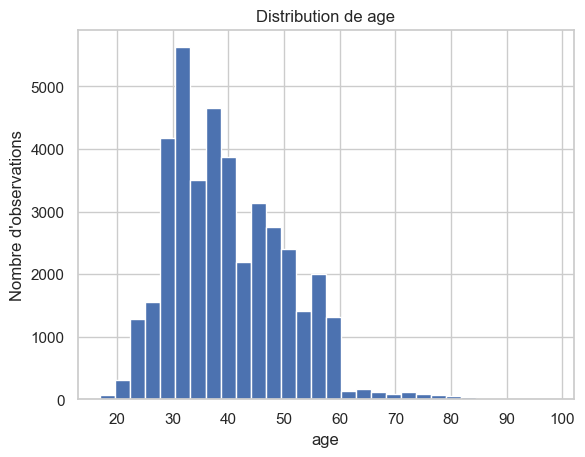

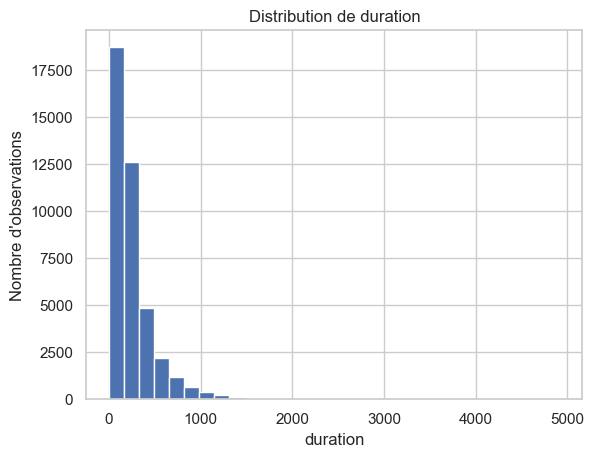

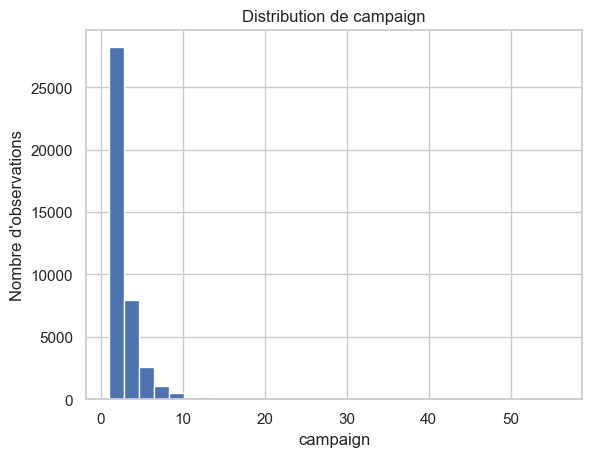

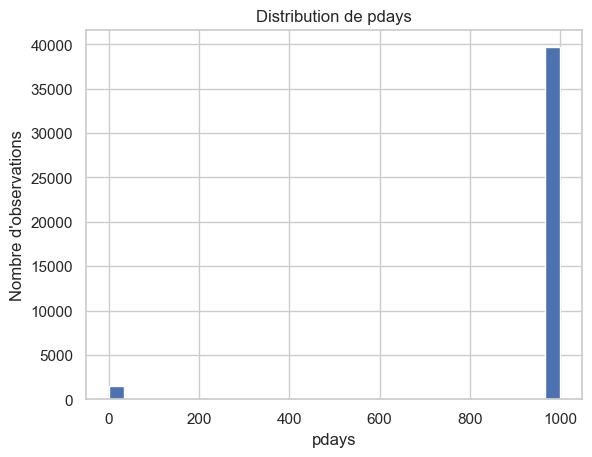

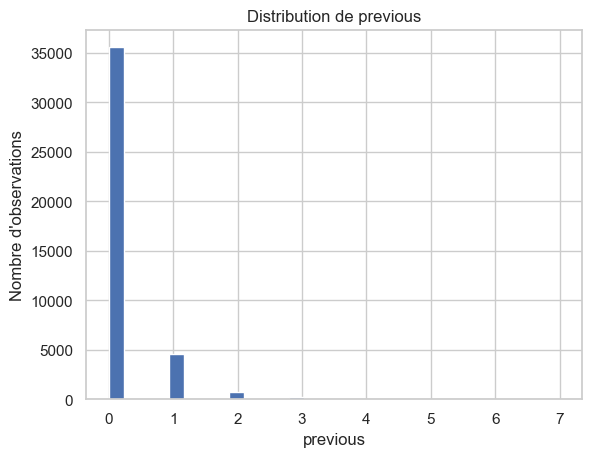

In [8]:
numeric_values = ["age", "duration", "campaign", "pdays", "previous"]

for col in numeric_values:
    df[col].hist(bins=30)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Nombre d'observations")
    plt.show()

Puis chercher un recoupement avec les souscriptions :

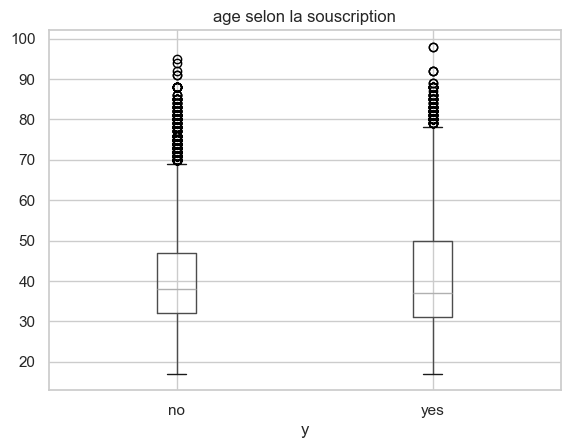

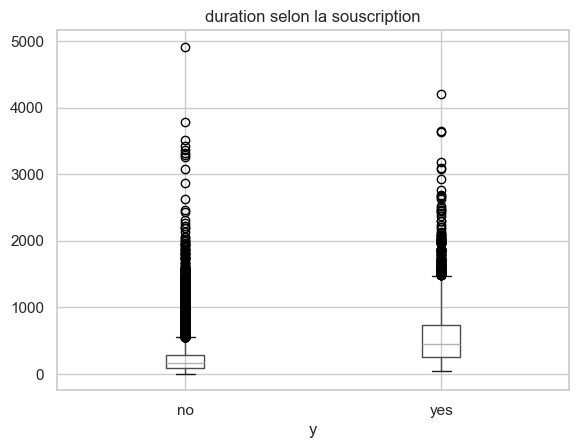

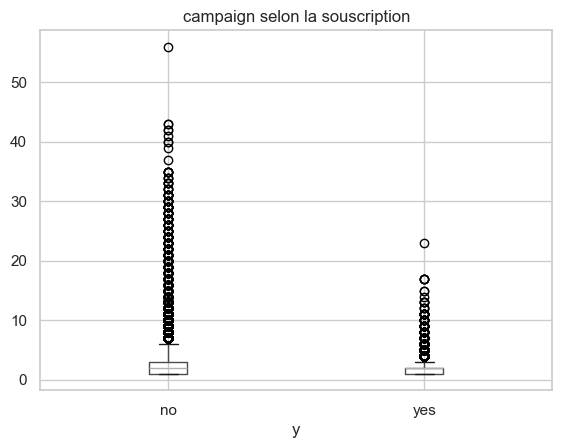

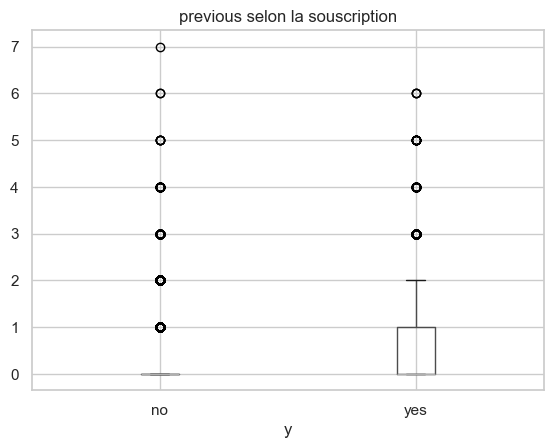

In [9]:
variables_to_compare = ["age", "duration", "campaign", "previous"]

for col in variables_to_compare:
    df.boxplot(column=col, by="y")
    plt.title(f"{col} selon la souscription")
    plt.suptitle("")
    plt.show()

### Cas particulier : `pdays`

`pdays` utilise la valeur `999` pour représenter un client qui n'avait jamais été
contacté auparavant. Une comparaison directe par boxplot mélangerait donc une
valeur codée avec de véritables nombres de jours, et ne serait pas pertinente.

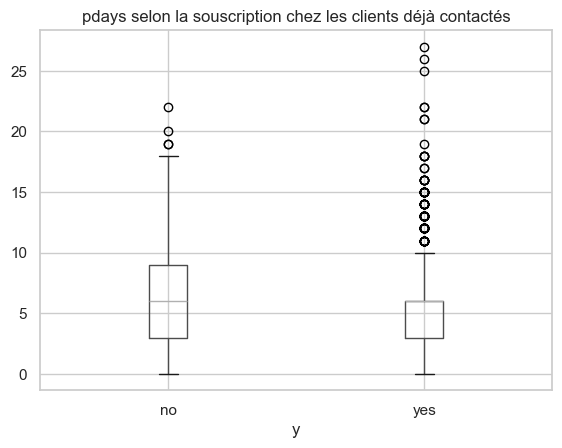

In [10]:
df[df["pdays"] != 999].boxplot(column="pdays", by="y")
plt.title("pdays selon la souscription chez les clients déjà contactés")
plt.suptitle("")
plt.show()

Nous allons ensuite chercher si certaines variables catégorielles sont rares ou dominantes :

In [11]:
categorical_values = df.select_dtypes(include="object").columns.drop("y")

for col in categorical_values:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(normalize=True).mul(100).round(2))


--- job ---
job
admin.           25.30
blue-collar      22.47
technician       16.37
services          9.64
management        7.10
retired           4.18
entrepreneur      3.54
self-employed     3.45
housemaid         2.57
unemployed        2.46
student           2.12
unknown           0.80
Name: proportion, dtype: float64

--- marital ---
marital
married     60.52
single      28.09
divorced    11.20
unknown      0.19
Name: proportion, dtype: float64

--- education ---
education
university.degree      29.54
high.school            23.10
basic.9y               14.68
professional.course    12.73
basic.4y               10.14
basic.6y                5.56
unknown                 4.20
illiterate              0.04
Name: proportion, dtype: float64

--- default ---
default
no         79.12
unknown    20.87
yes         0.01
Name: proportion, dtype: float64

--- housing ---
housing
yes        52.38
no         45.21
unknown     2.40
Name: proportion, dtype: float64

--- loan ---
loan
no         82

### Constats sur les variables catégorielles

L'analyse des fréquences montre plusieurs distributions déséquilibrées.

Certaines modalités sont très peu représentées, notamment `illiterate` pour
`education` et `yes` pour `default`, ce qui pourra rendre leur analyse statistique
moins robuste.

La variable `default` se distingue également par une proportion importante
de valeurs `unknown`.

`poutcome` est très majoritairement égal à `nonexistent`, indiquant que la plupart
des clients ne disposent pas d'un résultat exploitable de campagne précédente.

À l'inverse, `day_of_week` présente une distribution relativement homogène.

## 3.4 Variable cible : équilibre des classes

In [12]:
target_counts = df["y"].value_counts()
target_rates = df["y"].value_counts(normalize=True).mul(100).round(2)

print("Effectifs :")
print(target_counts)

print("\nProportions :")
print(target_rates.astype(str) + "%")

Effectifs :
y
no     36548
yes     4640
Name: count, dtype: int64

Proportions :
y
no     88.73%
yes    11.27%
Name: proportion, dtype: object


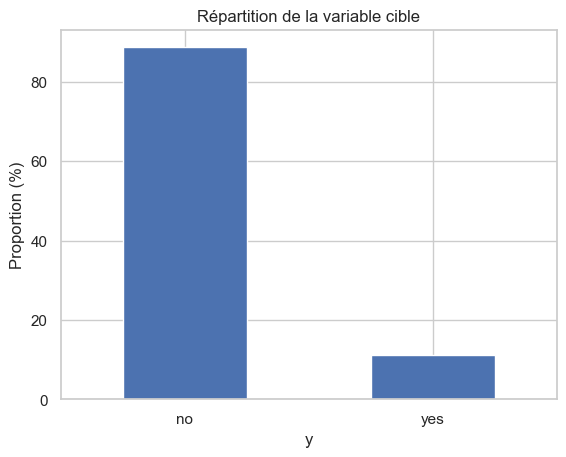

In [13]:
target_rates.plot(kind="bar")

plt.ylabel("Proportion (%)")
plt.title("Répartition de la variable cible")
plt.xticks(rotation=0)
plt.show()

La variable cible est fortement déséquilibrée :

- `no` représente 88,73 % des observations ;
- `yes` représente 11,27 % des observations.

La classe correspondant à la souscription est donc minoritaire.

Ce déséquilibre devra être pris en compte lors de l'évaluation des modèles.
L'accuracy seule serait insuffisante : un modèle prédisant systématiquement
`no` obtiendrait déjà une accuracy de 88,73 % sans permettre d'identifier
les clients susceptibles de souscrire.

Les performances devront donc également être évaluées à l'aide de métriques
adaptées à la classe positive, notamment la précision, le rappel, le F1-score,
la ROC-AUC et la matrice de confusion.

## 3.5 Corrélations & relations entre variables

L'objectif de cette section est d'identifier :
- d'éventuelles redondances entre variables numériques ;
- les variables présentant les relations les plus visibles avec la variable cible.

In [14]:
numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()

corr

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


### Corrélations entre variables numériques

La matrice de corrélation met en évidence plusieurs relations fortes entre les variables macro-économiques.

En particulier, `emp.var.rate`, `euribor3m` et `nr.employed` sont fortement corrélées entre elles, ce qui suggère qu'elles véhiculent en partie une information redondante sur le contexte économique.

À l'inverse, les variables liées directement au client ou à la campagne, comme `age`, `duration` ou `campaign`, présentent globalement de faibles corrélations linéaires avec les autres variables numériques.

Ces corrélations ne justifient pas à elles seules la suppression de variables, mais elles devront être prises en compte lors de la modélisation.

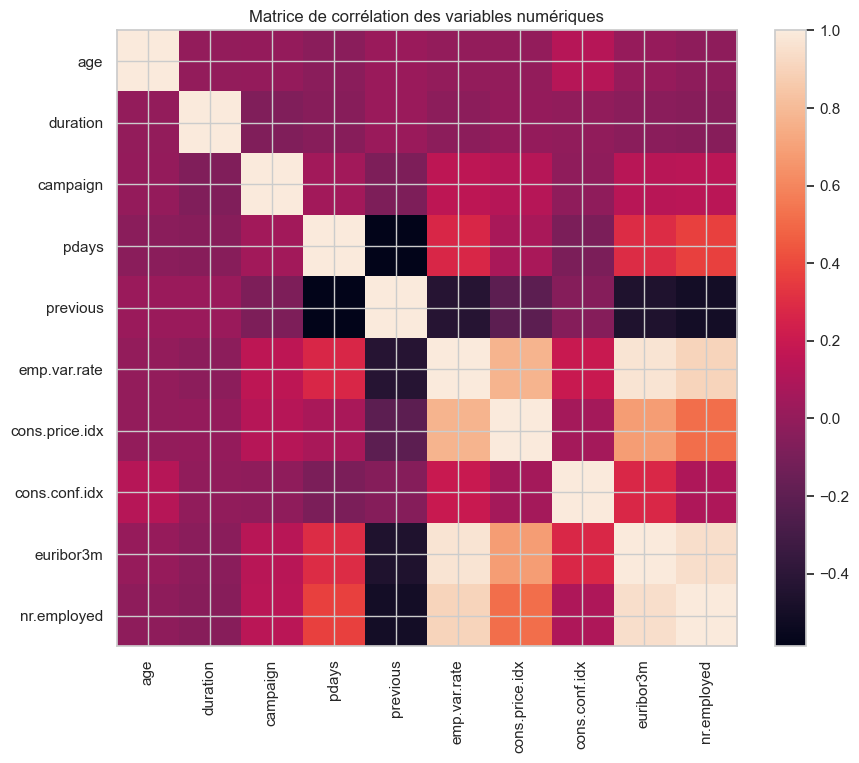

In [15]:
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()
plt.title("Matrice de corrélation des variables numériques")
plt.show()

Après avoir étudié la répartition propre de chaque variable catégorielle, nous cherchons maintenant à mesurer leur relation avec la variable cible.

Pour chaque modalité, nous calculons donc la proportion de clients ayant souscrit afin d’identifier d’éventuelles différences de taux de souscription entre les groupes.

In [16]:
categorical_to_compare = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "poutcome"
]

for col in categorical_to_compare:
    rates = (
        df.groupby(col)["y"]
        .apply(lambda x: (x == "yes").mean())
        .sort_values(ascending=False)
        .mul(100)
        .round(2)
    )

    print(f"\n--- {col} ---")
    print(rates)


--- job ---
job
student          31.43
retired          25.23
unemployed       14.20
admin.           12.97
management       11.22
unknown          11.21
technician       10.83
self-employed    10.49
housemaid        10.00
entrepreneur      8.52
services          8.14
blue-collar       6.89
Name: y, dtype: float64

--- marital ---
marital
unknown     15.00
single      14.00
divorced    10.32
married     10.16
Name: y, dtype: float64

--- education ---
education
illiterate             22.22
unknown                14.50
university.degree      13.72
professional.course    11.35
high.school            10.84
basic.4y               10.25
basic.6y                8.20
basic.9y                7.82
Name: y, dtype: float64

--- default ---
default
no         12.88
unknown     5.15
yes         0.00
Name: y, dtype: float64

--- housing ---
housing
yes        11.62
no         10.88
unknown    10.81
Name: y, dtype: float64

--- loan ---
loan
no         11.34
yes        10.93
unknown    10.81
Name: y

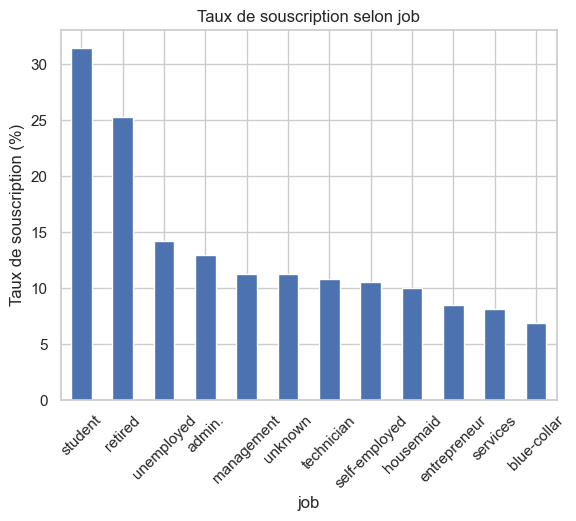

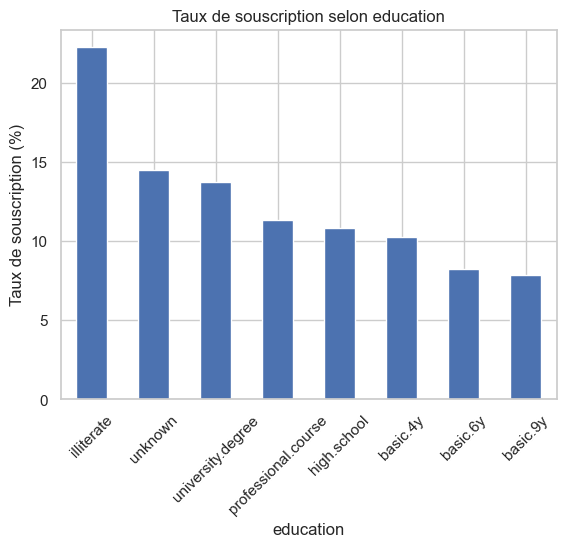

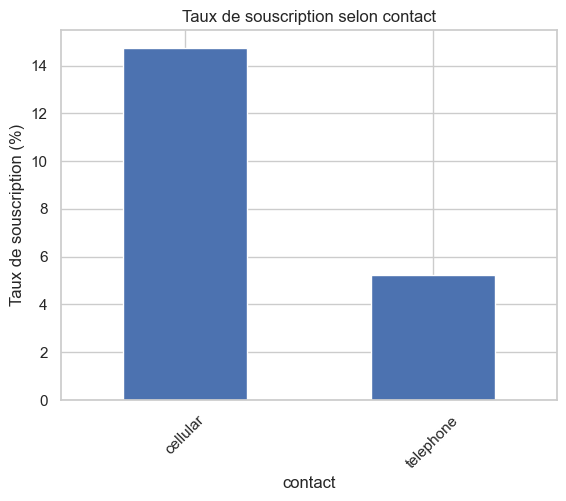

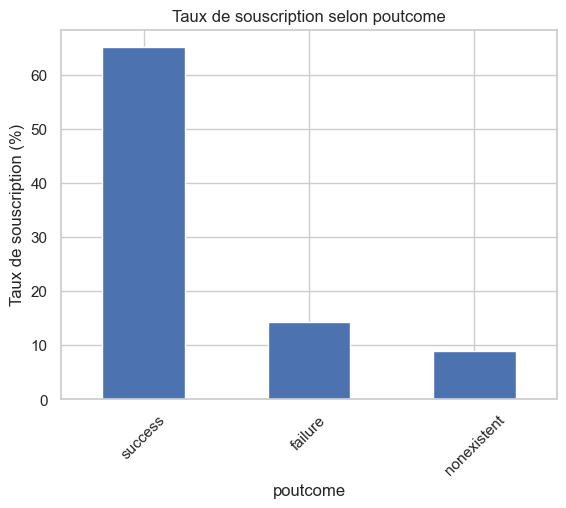

In [17]:
for col in ["job", "education", "contact", "poutcome"]:
    rates = (
        df.groupby(col)["y"]
        .apply(lambda x: (x == "yes").mean())
        .sort_values(ascending=False)
        .mul(100)
    )

    rates.plot(kind="bar")
    plt.ylabel("Taux de souscription (%)")
    plt.title(f"Taux de souscription selon {col}")
    plt.xticks(rotation=45)
    plt.show()

## 3.6 Analyse des biais & variables sensibles

Certaines variables décrivent directement le profil socio-démographique du client et
peuvent entraîner des différences de traitement entre groupes, notamment :

- `age`
- `job`
- `marital`
- `education`

À ce stade, avant l'entraînement d'un modèle, nous pouvons vérifier si la variable cible
est répartie différemment entre ces groupes et si certains d'entre eux sont très peu
représentés.

L'analyse des biais liée aux prédictions du modèle (taux de sélection, faux positifs,
faux négatifs, disparate impact) sera complétée après la phase de modélisation.

In [ ]:
bias_variables = ["job", "marital", "education"]

for col in bias_variables:
    rates = (
        df.groupby(col)["y"]
        .apply(lambda x: (x == "yes").mean())
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
    )

    print(f"\n--- Taux de souscription selon {col} ---")
    print(rates)

In [ ]:
age_group = pd.cut(
    df["age"],
    bins=[0, 30, 40, 50, 60, float("inf")],
    labels=["<30", "30-39", "40-49", "50-59", "60+"]
)

age_subscription_rate = (
    df.assign(age_group=age_group)
    .groupby("age_group", observed=False)["y"]
    .apply(lambda x: (x == "yes").mean())
    .mul(100)
    .round(2)
)

age_subscription_rate

Plusieurs variables socio-démographiques présentent des différences de taux de souscription entre les groupes.

La profession (`job`) montre des écarts importants : certaines catégories comme les étudiants ou les retraités présentent un taux de souscription nettement supérieur à d'autres, comme les ouvriers (`blue-collar`).

Le niveau d'éducation présente également des écarts visibles, mais certaines modalités sont très peu représentées, ce qui limite la robustesse des comparaisons.

L'âge montre une différence particulièrement marquée : les clients de 60 ans et plus présentent un taux de souscription beaucoup plus élevé que les autres tranches d'âge.

Ces écarts ne démontrent pas à eux seuls l'existence d'un biais du modèle, puisqu'aucun modèle n'a encore été entraîné. Ils montrent toutefois que certaines variables sensibles ou socio-démographiques sont fortement associées à la cible et devront faire l'objet d'une attention particulière lors de la modélisation et de l'évaluation de l'équité.

L'analyse des biais sur les prédictions du modèle, notamment les taux de sélection, faux positifs, faux négatifs et éventuel disparate impact, sera réalisée après entraînement.

## 3.7 Synthèse EDA

L'analyse exploratoire met en évidence plusieurs éléments importants pour la suite du projet :

1. La qualité générale des données est bonne : aucune valeur `NaN` n'est présente. Certaines variables contiennent toutefois la modalité `unknown`, particulièrement `default`.

2. La variable cible est fortement déséquilibrée : seulement 11,27 % des observations correspondent à une souscription. L'accuracy seule ne sera donc pas suffisante pour évaluer les modèles.

3. Certaines variables présentent des particularités nécessitant un traitement ou une interprétation spécifique, notamment `pdays`, dont la valeur `999` signifie que le client n'avait jamais été contacté auparavant.

4. Plusieurs variables macro-économiques, notamment `emp.var.rate`, `euribor3m` et `nr.employed`, sont fortement corrélées entre elles, ce qui suggère une redondance potentielle.

5. Plusieurs variables socio-démographiques présentent des différences importantes de taux de souscription selon les groupes, en particulier `age` et `job`. Elles devront donc être analysées avec attention afin de limiter les risques de biais ou de traitement différencié.

Enfin, `duration` semble fortement liée à la cible, mais cette information n'est disponible qu'après la fin de l'appel. Elle ne pourra donc pas être utilisée directement dans un modèle destiné à décider en amont quels clients contacter.

### Conséquences pour la modélisation

La suite du projet devra :
- utiliser des métriques adaptées à la classe minoritaire, notamment précision, rappel et F1-score ;
- comparer les performances avec et sans `duration` ;
- analyser l'impact des variables socio-démographiques ;
- contrôler les performances du modèle par sous-groupes afin d'identifier d'éventuels biais.